<a href="https://colab.research.google.com/github/muhammed-ajlan/Host-Based-Intrusion-Detection-System/blob/main/Python__code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/yianqaq/adfa-ld/run.py
/kaggle/input/datasets/yianqaq/adfa-ld/Question Statement Assignment.pdf
/kaggle/input/datasets/yianqaq/adfa-ld/TRAINING/ATTACK-4/top30%_7tupple.txt
/kaggle/input/datasets/yianqaq/adfa-ld/TRAINING/ATTACK-4/top30%_3tupple.txt
/kaggle/input/datasets/yianqaq/adfa-ld/TRAINING/ATTACK-4/top30%_5tupple.txt
/kaggle/input/datasets/yianqaq/adfa-ld/TRAINING/ATTACK-6/top30%_7tupple.txt
/kaggle/input/datasets/yianqaq/adfa-ld/TRAINING/ATTACK-6/top30%_3tupple.txt
/kaggle/input/datasets/yianqaq/adfa-ld/TRAINING/ATTACK-6/top30%_5tupple.txt
/kaggle/input/datasets/yianqaq/adfa-ld/TRAINING/ATTACK-5/top30%_7tupple.txt
/kaggle/input/datasets/yianqaq/adfa-ld/TRAINING/ATTACK-5/top30%_3tupple.txt
/kaggle/input/datasets/yianqaq/adfa-ld/TRAINING/ATTACK-5/top30%_5tupple.txt
/kaggle/input/datasets/yianqaq/adfa-ld/TRAINING/ATTACK-3/top30%_7tupple.txt
/kaggle/input/datasets/yianqaq/adfa-ld/TRAINING/ATTACK-3/top30%_3tupple.txt
/kaggle/input/datasets/yianqaq/adfa-ld/TRAINI

In [ ]:
import os
import time
import glob
import psutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    accuracy_score
)

print("All libraries imported successfully!")
print(f"NumPy version    : {np.__version__}")

All libraries imported successfully!
NumPy version    : 2.0.2


In [ ]:
# First, let's see what's inside the dataset
import os

dataset_path = "/kaggle/input/datasets/yianqaq/adfa-ld"

for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 3:  # only show files up to 3 levels deep
        subindent = ' ' * 2 * (level + 1)
        for file in files[:5]:  # show first 5 files per folder
            print(f"{subindent}{file}")
        if len(files) > 5:
            print(f"{subindent}... and {len(files)-5} more files")

adfa-ld/
  run.py
  Question Statement Assignment.pdf
  TRAINING/
    ATTACK-4/
      top30%_7tupple.txt
      top30%_3tupple.txt
      top30%_5tupple.txt
    ATTACK-6/
      top30%_7tupple.txt
      top30%_3tupple.txt
      top30%_5tupple.txt
    ATTACK-5/
      top30%_7tupple.txt
      top30%_3tupple.txt
      top30%_5tupple.txt
    ATTACK-3/
      top30%_7tupple.txt
      top30%_3tupple.txt
      top30%_5tupple.txt
    ATTACK-1/
      top30%_7tupple.txt
      top30%_3tupple.txt
      top30%_5tupple.txt
    NORMAL/
      top30%7tupple.txt
      top30%3tupple.txt
      top30%5tupple.txt
    ATTACK-2/
      top30%_7tupple.txt
      top30%_3tupple.txt
      top30%_5tupple.txt
  ADFA-LD/
    Training_Data_Master/
      UTD-0592.txt
      UTD-0789.txt
      UTD-0550.txt
      UTD-0603.txt
      UTD-0359.txt
      ... and 828 more files
    Validation_Data_Master/
      UVD-4337.txt
      UVD-1216.txt
      UVD-2195.txt
      UVD-0843.txt
      UVD-0404.txt
      ... and 4368 more files
  

In [ ]:
def load_traces_from_folder(folder_path):
    """
    Load all system call trace files from a folder.
    Each file contains space-separated integer syscall IDs.
    Returns a list of traces (each trace = list of integers).
    """
    traces = []
    file_paths = []

    # Find all .txt files recursively
    pattern = os.path.join(folder_path, '**', '*.txt')
    files = glob.glob(pattern, recursive=True)

    if not files:
        # Try without extension
        pattern = os.path.join(folder_path, '**', '*')
        files = [f for f in glob.glob(pattern, recursive=True)
                 if os.path.isfile(f)]

    for filepath in sorted(files):
        try:
            with open(filepath, 'r') as f:
                content = f.read().strip()
                if content:
                    # Parse space-separated syscall IDs
                    calls = list(map(int, content.split()))
                    if len(calls) > 0:
                        traces.append(calls)
                        file_paths.append(filepath)
        except Exception as e:
            pass  # skip unreadable files

    return traces, file_paths


# ─── FIND CORRECT PATHS ───
# Common ADFA-LD folder structures on Kaggle:
possible_normal_paths = [
    "/kaggle/input/datasets/yianqaq/adfa-ld/ADFA-LD/Training_Data_Master",

]

possible_attack_paths = [
    "/kaggle/input/datasets/yianqaq/adfa-ld/ADFA-LD/Attack_Data_Master",

]

# Auto-detect which path exists
normal_path = None
attack_path = None

for p in possible_normal_paths:
    if os.path.exists(p):
        normal_path = p
        break

for p in possible_attack_paths:
    if os.path.exists(p):
        attack_path = p
        break

if normal_path is None or attack_path is None:
    print("Could not auto-detect paths. Scanning dataset folder...")
    for root, dirs, files in os.walk("/kaggle/input/adfa-ld"):
        if files:
            print(f"Found files at: {root}")
else:
    print(f"Normal data path : {normal_path}")
    print(f"Attack data path : {attack_path}")

Normal data path : /kaggle/input/datasets/yianqaq/adfa-ld/ADFA-LD/Training_Data_Master
Attack data path : /kaggle/input/datasets/yianqaq/adfa-ld/ADFA-LD/Attack_Data_Master


In [ ]:
# ─── LOAD TRACES ───
print("Loading normal traces...")
normal_traces, normal_files = load_traces_from_folder(normal_path)

print("Loading attack traces...")
attack_traces, attack_files = load_traces_from_folder(attack_path)

# ─── SUMMARY ───
print("\n" + "="*50)
print("       DATASET LOADING SUMMARY")
print("="*50)
print(f"Normal traces loaded  : {len(normal_traces)}")
print(f"Attack traces loaded  : {len(attack_traces)}")
print(f"Total traces          : {len(normal_traces) + len(attack_traces)}")

# Trace length statistics
normal_lengths = [len(t) for t in normal_traces]
attack_lengths = [len(t) for t in attack_traces]

print(f"\nNormal trace lengths  : min={min(normal_lengths)}, "
      f"max={max(normal_lengths)}, "
      f"avg={np.mean(normal_lengths):.1f}")
print(f"Attack trace lengths  : min={min(attack_lengths)}, "
      f"max={max(attack_lengths)}, "
      f"avg={np.mean(attack_lengths):.1f}")

# Unique syscalls
all_normal_calls = set(c for t in normal_traces for c in t)
all_attack_calls = set(c for t in attack_traces for c in t)

print(f"\nUnique syscall IDs in normal traces : {len(all_normal_calls)}")
print(f"Unique syscall IDs in attack traces : {len(all_attack_calls)}")
print(f"Syscall IDs only in attacks         : "
      f"{len(all_attack_calls - all_normal_calls)}")

# Show sample trace
print(f"\nSample normal trace (first 15 calls): {normal_traces[0][:15]}")
print(f"Sample attack trace (first 15 calls): {attack_traces[0][:15]}")

# ─── ATTACK TYPES BREAKDOWN ───
print("\n" + "="*50)
print("       ATTACK TYPE BREAKDOWN")
print("="*50)

attack_type_counts = defaultdict(int)
for filepath in attack_files:
    # Folder name = attack type
    attack_type = os.path.basename(os.path.dirname(filepath))
    attack_type_counts[attack_type] += 1

for attack_type, count in sorted(attack_type_counts.items()):
    print(f"  {attack_type:<30} : {count} traces")

Loading normal traces...
Loading attack traces...

       DATASET LOADING SUMMARY
Normal traces loaded  : 833
Attack traces loaded  : 746
Total traces          : 1579

Normal trace lengths  : min=79, max=2948, avg=369.8
Attack trace lengths  : min=75, max=2712, avg=425.5

Unique syscall IDs in normal traces : 150
Unique syscall IDs in attack traces : 90
Syscall IDs only in attacks         : 3

Sample normal trace (first 15 calls): [6, 6, 63, 6, 42, 120, 6, 195, 120, 6, 6, 114, 114, 1, 1]
Sample attack trace (first 15 calls): [265, 168, 168, 265, 168, 168, 168, 265, 168, 265, 168, 168, 168, 168, 168]

       ATTACK TYPE BREAKDOWN
  Adduser_1                      : 7 traces
  Adduser_10                     : 6 traces
  Adduser_2                      : 8 traces
  Adduser_3                      : 8 traces
  Adduser_4                      : 7 traces
  Adduser_5                      : 10 traces
  Adduser_6                      : 8 traces
  Adduser_7                      : 8 traces
  Adduser_

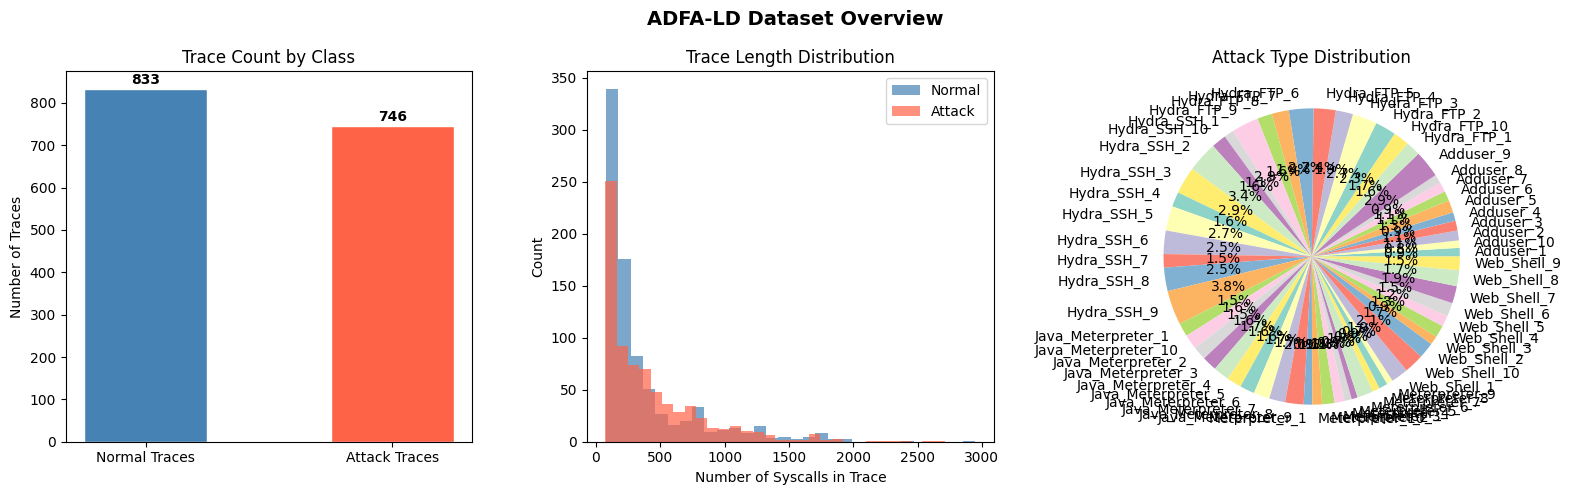

Dataset overview saved!


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("ADFA-LD Dataset Overview", fontsize=14, fontweight='bold')

# Plot 1: Trace count bar chart
ax = axes[0]
categories = ['Normal Traces', 'Attack Traces']
counts = [len(normal_traces), len(attack_traces)]
colors = ['steelblue', 'tomato']
bars = ax.bar(categories, counts, color=colors, edgecolor='white', width=0.5)
ax.set_title("Trace Count by Class")
ax.set_ylabel("Number of Traces")
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 5,
            str(count), ha='center', va='bottom', fontweight='bold')

# Plot 2: Trace length distribution
ax = axes[1]
ax.hist(normal_lengths, bins=30, alpha=0.7, color='steelblue', label='Normal')
ax.hist(attack_lengths, bins=30, alpha=0.7, color='tomato', label='Attack')
ax.set_title("Trace Length Distribution")
ax.set_xlabel("Number of Syscalls in Trace")
ax.set_ylabel("Count")
ax.legend()

# Plot 3: Attack types pie chart
ax = axes[2]
if attack_type_counts:
    labels = list(attack_type_counts.keys())
    sizes  = list(attack_type_counts.values())
    ax.pie(sizes, labels=labels, autopct='%1.1f%%',
           colors=plt.cm.Set3.colors[:len(labels)])
    ax.set_title("Attack Type Distribution")

plt.tight_layout()
plt.savefig("dataset_overview.png", dpi=150, bbox_inches='tight')
plt.show()
print("Dataset overview saved!")

In [ ]:
def extract_ngrams(trace, n=3):
    """
    Extract all n-grams from a syscall trace using sliding window.

    Args:
        trace : list of integer syscall IDs
        n     : window size (default=3)

    Returns:
        set of n-gram tuples
    """
    return set(
        tuple(trace[i:i+n])
        for i in range(len(trace) - n + 1)
    )


# ─── APPLY TO ALL TRACES ───
N = 3  # n-gram size

print(f"Extracting {N}-grams from all traces...")

start_time = time.perf_counter()
normal_ngrams = [extract_ngrams(t, N) for t in normal_traces]
attack_ngrams = [extract_ngrams(t, N) for t in attack_traces]
end_time = time.perf_counter()

print(f"Extraction completed in {(end_time - start_time)*1000:.2f} ms")

# Statistics
normal_ngram_counts = [len(g) for g in normal_ngrams]
attack_ngram_counts = [len(g) for g in attack_ngrams]

print(f"\nN-gram Statistics (n={N}):")
print(f"  Normal — avg: {np.mean(normal_ngram_counts):.1f}, "
      f"min: {min(normal_ngram_counts)}, "
      f"max: {max(normal_ngram_counts)}")
print(f"  Attack — avg: {np.mean(attack_ngram_counts):.1f}, "
      f"min: {min(attack_ngram_counts)}, "
      f"max: {max(attack_ngram_counts)}")

# Show example
sample_trace = normal_traces[0][:8]
sample_ngrams = extract_ngrams(sample_trace, N)
print(f"\nExample trace   : {sample_trace}")
print(f"Extracted {N}-grams : {sorted(sample_ngrams)}")

Extracting 3-grams from all traces...
Extraction completed in 173.48 ms

N-gram Statistics (n=3):
  Normal — avg: 88.7, min: 1, max: 502
  Attack — avg: 76.8, min: 1, max: 371

Example trace   : [6, 6, 63, 6, 42, 120, 6, 195]
Extracted 3-grams : [(6, 6, 63), (6, 42, 120), (6, 63, 6), (42, 120, 6), (63, 6, 42), (120, 6, 195)]


In [ ]:
# ─── TRAIN / TEST SPLIT ───
np.random.seed(42)
indices = np.random.permutation(len(normal_traces))

split = int(0.8 * len(normal_traces))
train_idx = indices[:split]
test_idx  = indices[split:]

train_normal_ngrams = [normal_ngrams[i] for i in train_idx]
test_normal_ngrams  = [normal_ngrams[i] for i in test_idx]
train_normal_traces = [normal_traces[i] for i in train_idx]
test_normal_traces  = [normal_traces[i] for i in test_idx]

print("Train/Test Split:")
print(f"  Training normal traces : {len(train_normal_ngrams)}")
print(f"  Testing  normal traces : {len(test_normal_ngrams)}")
print(f"  Attack   traces (test) : {len(attack_ngrams)}")

# ─── BUILD NORMAL PROFILE ───
print("\nBuilding normal behavior profile...")

build_start = time.perf_counter()
normal_profile = set()
for ngram_set in train_normal_ngrams:
    normal_profile.update(ngram_set)
build_end = time.perf_counter()

print(f"Profile built in {(build_end - build_start)*1000:.2f} ms")
print(f"Normal profile size : {len(normal_profile):,} unique {N}-grams")

# Coverage check — how well does profile cover test normal traces?
coverage_scores = []
for ngram_set in test_normal_ngrams:
    if ngram_set:
        known = ngram_set & normal_profile
        coverage_scores.append(len(known) / len(ngram_set))

print(f"\nProfile coverage on test normal traces:")
print(f"  Mean  : {np.mean(coverage_scores)*100:.2f}%")
print(f"  Median: {np.median(coverage_scores)*100:.2f}%")
print(f"  Min   : {min(coverage_scores)*100:.2f}%")

Train/Test Split:
  Training normal traces : 666
  Testing  normal traces : 167
  Attack   traces (test) : 746

Building normal behavior profile...
Profile built in 6.16 ms
Normal profile size : 9,321 unique 3-grams

Profile coverage on test normal traces:
  Mean  : 93.42%
  Median: 95.00%
  Min   : 60.18%


In [ ]:
def anomaly_score(ngram_set, profile):
    """
    Compute anomaly score for a trace.

    Score = fraction of n-grams NOT in the normal profile.
    Score = 0.0 --> fully normal
    Score = 1.0 --> fully unknown (attack)
    """
    if not ngram_set:
        return 0.0
    unseen = ngram_set - profile
    return len(unseen) / len(ngram_set)


# ─── SCORE ALL TEST TRACES ───
print("Computing anomaly scores...")

normal_scores = [anomaly_score(g, normal_profile)
                 for g in test_normal_ngrams]
attack_scores = [anomaly_score(g, normal_profile)
                 for g in attack_ngrams]

print(f"\nAnomaly Score Statistics:")
print(f"  Normal traces — mean: {np.mean(normal_scores):.4f}, "
      f"std: {np.std(normal_scores):.4f}")
print(f"  Attack traces — mean: {np.mean(attack_scores):.4f}, "
      f"std: {np.std(attack_scores):.4f}")

# ─── ROC CURVE & OPTIMAL THRESHOLD ───
all_scores = normal_scores + attack_scores
all_labels  = [0] * len(normal_scores) + [1] * len(attack_scores)

fpr, tpr, thresholds = roc_curve(all_labels, all_scores)
roc_auc = auc(fpr, tpr)

# Best threshold = maximise (TPR - FPR)
best_idx       = np.argmax(tpr - fpr)
best_threshold = thresholds[best_idx]

print(f"\nROC-AUC Score      : {roc_auc:.4f}")
print(f"Best Threshold     : {best_threshold:.4f}")
print(f"  TPR at threshold : {tpr[best_idx]:.4f} "
      f"({tpr[best_idx]*100:.1f}% attacks caught)")
print(f"  FPR at threshold : {fpr[best_idx]:.4f} "
      f"({fpr[best_idx]*100:.1f}% false alarms)")

# ─── CLASSIFY ───
predictions = [1 if s > best_threshold else 0 for s in all_scores]

print("\n" + "="*50)
print("     CLASSIFICATION REPORT")
print("="*50)
print(classification_report(
    all_labels, predictions,
    target_names=["Normal", "Attack"]
))

acc = accuracy_score(all_labels, predictions)
print(f"Overall Accuracy : {acc*100:.2f}%")

# ─── PER ATTACK TYPE DETECTION ───
print("\n" + "="*50)
print("     PER ATTACK TYPE DETECTION RATE")
print("="*50)

attack_type_files = {}
for filepath in attack_files:
    atype = os.path.basename(os.path.dirname(filepath))
    if atype not in attack_type_files:
        attack_type_files[atype] = []
    attack_type_files[atype].append(filepath)

# Map file to index in attack_traces
file_to_idx = {f: i for i, f in enumerate(attack_files)}

for atype, files in sorted(attack_type_files.items()):
    idxs = [file_to_idx[f] for f in files if f in file_to_idx]
    if idxs:
        type_scores = [attack_scores[i] for i in idxs]
        type_preds  = [1 if s > best_threshold else 0
                       for s in type_scores]
        dr = sum(type_preds) / len(type_preds) * 100
        print(f"  {atype:<30} : {dr:.1f}% detected "
              f"({sum(type_preds)}/{len(type_preds)} traces)")

Computing anomaly scores...

Anomaly Score Statistics:
  Normal traces — mean: 0.0658, std: 0.0715
  Attack traces — mean: 0.2890, std: 0.2825

ROC-AUC Score      : 0.7182
Best Threshold     : 0.1400
  TPR at threshold : 0.5751 (57.5% attacks caught)
  FPR at threshold : 0.1198 (12.0% false alarms)

     CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Normal       0.32      0.88      0.47       167
      Attack       0.96      0.57      0.72       746

    accuracy                           0.63       913
   macro avg       0.64      0.73      0.59       913
weighted avg       0.84      0.63      0.67       913

Overall Accuracy : 62.98%

     PER ATTACK TYPE DETECTION RATE
  Adduser_1                      : 71.4% detected (5/7 traces)
  Adduser_10                     : 50.0% detected (3/6 traces)
  Adduser_2                      : 50.0% detected (4/8 traces)
  Adduser_3                      : 50.0% detected (4/8 traces)
  Adduser_4                   

In [ ]:
print("Measuring detection latency...")
print("(Running 200 traces: 100 normal + 100 attack)\n")

latencies_normal = []
latencies_attack = []

# Measure for normal traces
sample_normal = test_normal_traces[:100]
for trace in sample_normal:
    start = time.perf_counter()
    ngrams = extract_ngrams(trace, N)
    score  = anomaly_score(ngrams, normal_profile)
    pred   = 1 if score > best_threshold else 0
    end    = time.perf_counter()
    latencies_normal.append((end - start) * 1000)

# Measure for attack traces
sample_attack = attack_traces[:100]
for trace in sample_attack:
    start = time.perf_counter()
    ngrams = extract_ngrams(trace, N)
    score  = anomaly_score(ngrams, normal_profile)
    pred   = 1 if score > best_threshold else 0
    end    = time.perf_counter()
    latencies_attack.append((end - start) * 1000)

all_latencies = np.array(latencies_normal + latencies_attack)
lat_normal    = np.array(latencies_normal)
lat_attack    = np.array(latencies_attack)

print("="*50)
print("     DETECTION LATENCY REPORT")
print("="*50)
print(f"\nAll Traces (200 total):")
print(f"  Mean   : {all_latencies.mean():.4f} ms")
print(f"  Median : {np.median(all_latencies):.4f} ms")
print(f"  Min    : {all_latencies.min():.4f} ms")
print(f"  Max    : {all_latencies.max():.4f} ms")
print(f"  Std    : {all_latencies.std():.4f} ms")
print(f"  P95    : {np.percentile(all_latencies, 95):.4f} ms")

print(f"\nNormal Traces (100):")
print(f"  Mean   : {lat_normal.mean():.4f} ms")

print(f"\nAttack Traces (100):")
print(f"  Mean   : {lat_attack.mean():.4f} ms")

# Throughput
throughput = 1000 / all_latencies.mean()
print(f"\nEstimated Throughput : {throughput:.0f} traces/second")

Measuring detection latency...
(Running 200 traces: 100 normal + 100 attack)

     DETECTION LATENCY REPORT

All Traces (200 total):
  Mean   : 0.1185 ms
  Median : 0.0759 ms
  Min    : 0.0169 ms
  Max    : 0.6611 ms
  Std    : 0.1148 ms
  P95    : 0.3540 ms

Normal Traces (100):
  Mean   : 0.1122 ms

Attack Traces (100):
  Mean   : 0.1248 ms

Estimated Throughput : 8440 traces/second


In [ ]:
import os
import psutil

process = psutil.Process(os.getpid())

# ─── BASELINE MEMORY ───
mem_before_mb = process.memory_info().rss / (1024 * 1024)

total_traces = normal_traces + attack_traces
total_count  = len(total_traces)

# ─── RUN FULL DETECTION ───
print(f"Running detection on all {total_count} traces...")

cpu_start = time.perf_counter()
all_preds_overhead = []
for trace in total_traces:
    ngrams = extract_ngrams(trace, N)
    score  = anomaly_score(ngrams, normal_profile)
    all_preds_overhead.append(1 if score > best_threshold else 0)
cpu_end = time.perf_counter()

# ─── POST-DETECTION MEMORY ───
mem_after_mb = process.memory_info().rss / (1024 * 1024)

total_time       = cpu_end - cpu_start
throughput_full  = total_count / total_time
mem_overhead     = mem_after_mb - mem_before_mb
profile_size_kb  = (len(normal_profile) * 3 * 8) / 1024

print("\n" + "="*50)
print("     SYSTEM OVERHEAD REPORT")
print("="*50)
print(f"Total traces processed    : {total_count}")
print(f"Total detection time      : {total_time:.4f} sec")
print(f"Throughput                : {throughput_full:.1f} traces/sec")
print(f"\nMemory before detection   : {mem_before_mb:.2f} MB")
print(f"Memory after detection    : {mem_after_mb:.2f} MB")
print(f"Memory overhead           : {mem_overhead:.2f} MB")
print(f"\nProfile size (n-grams)    : {len(normal_profile):,}")
print(f"Estimated profile RAM     : {profile_size_kb:.2f} KB")
print(f"\nAvg time per trace        : "
      f"{(total_time/total_count)*1000:.4f} ms")

Running detection on all 1579 traces...

     SYSTEM OVERHEAD REPORT
Total traces processed    : 1579
Total detection time      : 0.1653 sec
Throughput                : 9549.9 traces/sec

Memory before detection   : 272.76 MB
Memory after detection    : 272.76 MB
Memory overhead           : 0.00 MB

Profile size (n-grams)    : 9,321
Estimated profile RAM     : 218.46 KB

Avg time per trace        : 0.1047 ms


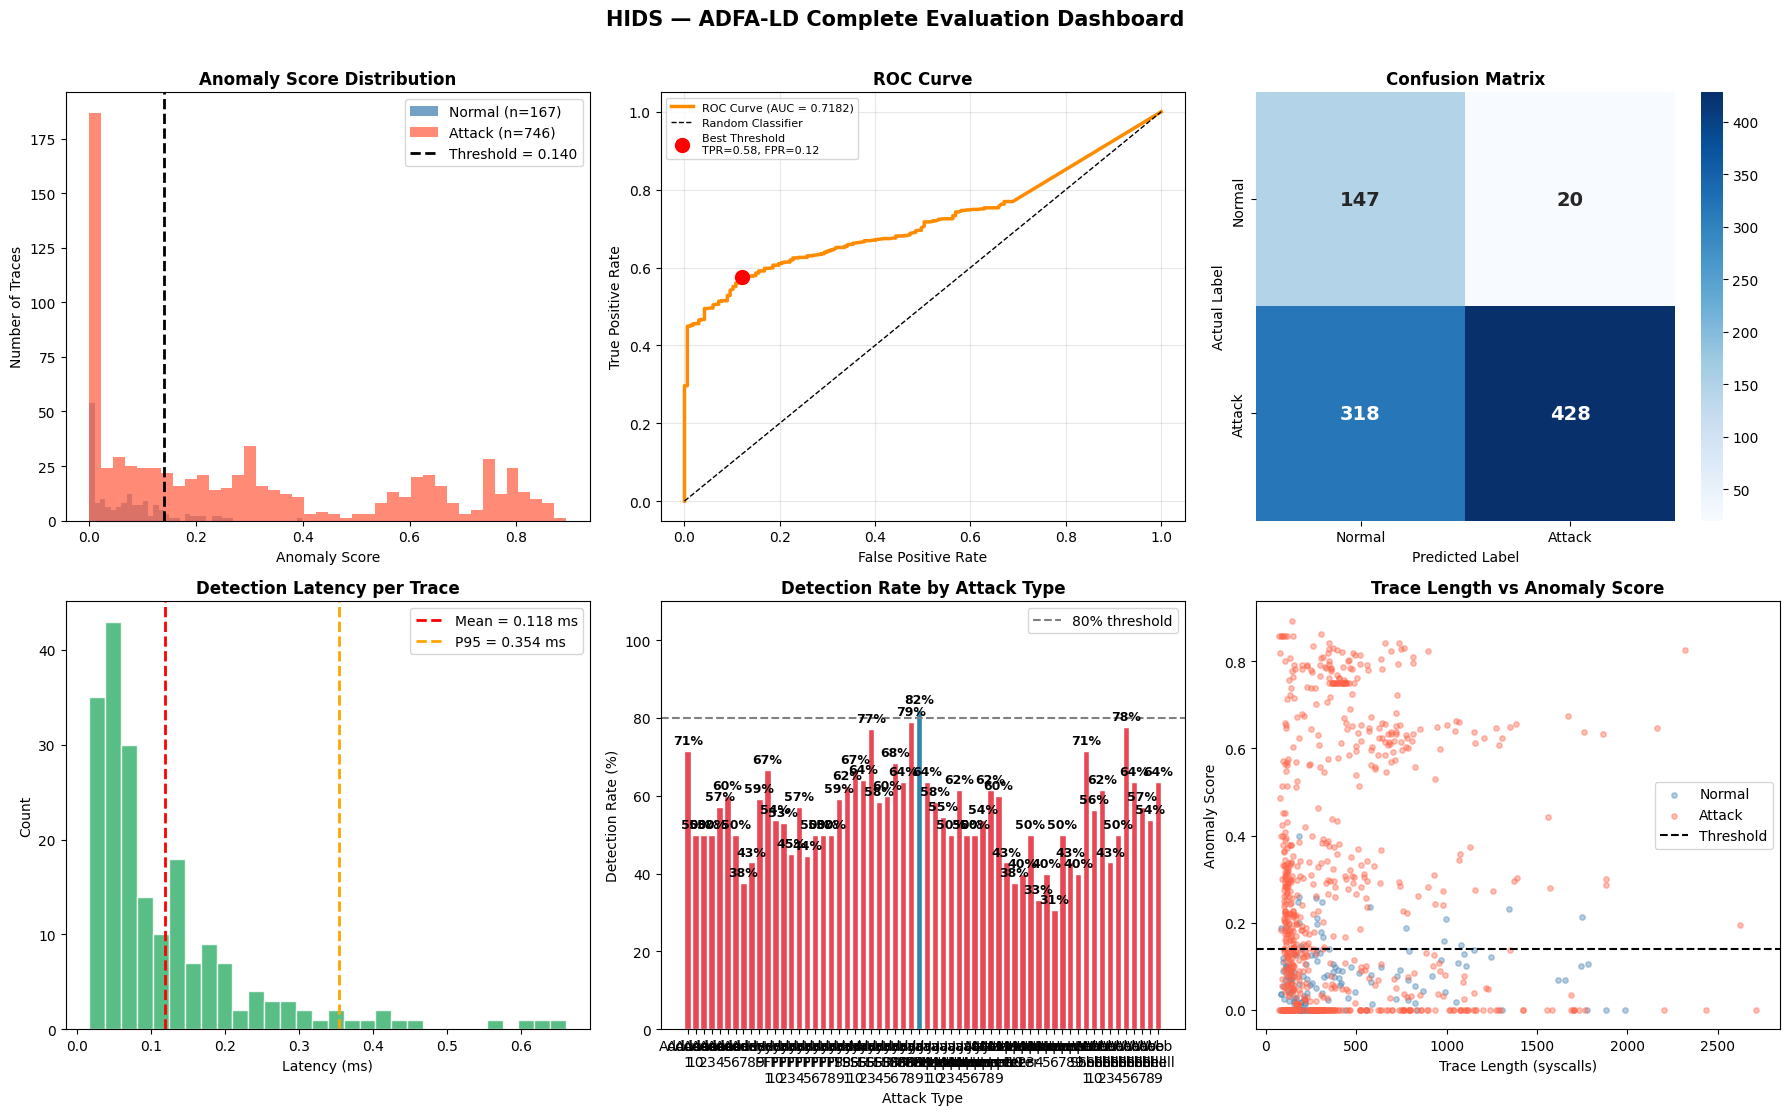

Full evaluation dashboard saved!


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle(
    "HIDS — ADFA-LD Complete Evaluation Dashboard",
    fontsize=15, fontweight='bold', y=1.01
)

# ── Plot 1: Anomaly Score Distribution ──
ax = axes[0, 0]
ax.hist(normal_scores, bins=40, alpha=0.75,
        color='steelblue', label=f'Normal (n={len(normal_scores)})')
ax.hist(attack_scores, bins=40, alpha=0.75,
        color='tomato', label=f'Attack (n={len(attack_scores)})')
ax.axvline(best_threshold, color='black', linestyle='--',
           linewidth=2, label=f'Threshold = {best_threshold:.3f}')
ax.set_title("Anomaly Score Distribution", fontweight='bold')
ax.set_xlabel("Anomaly Score")
ax.set_ylabel("Number of Traces")
ax.legend()

# ── Plot 2: ROC Curve ──
ax = axes[0, 1]
ax.plot(fpr, tpr, color='darkorange', lw=2.5,
        label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
ax.scatter(fpr[best_idx], tpr[best_idx], color='red',
           zorder=5, s=100,
           label=f'Best Threshold\nTPR={tpr[best_idx]:.2f}, FPR={fpr[best_idx]:.2f}')
ax.set_title("ROC Curve", fontweight='bold')
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# ── Plot 3: Confusion Matrix ──
ax = axes[0, 2]
cm = confusion_matrix(all_labels, predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'],
            annot_kws={"size": 14, "weight": "bold"})
ax.set_title("Confusion Matrix", fontweight='bold')
ax.set_xlabel("Predicted Label")
ax.set_ylabel("Actual Label")

# ── Plot 4: Detection Latency ──
ax = axes[1, 0]
ax.hist(all_latencies, bins=30, color='mediumseagreen',
        edgecolor='white', alpha=0.85)
ax.axvline(all_latencies.mean(), color='red', linestyle='--',
           lw=2, label=f'Mean = {all_latencies.mean():.3f} ms')
ax.axvline(np.percentile(all_latencies, 95), color='orange',
           linestyle='--', lw=2,
           label=f'P95 = {np.percentile(all_latencies, 95):.3f} ms')
ax.set_title("Detection Latency per Trace", fontweight='bold')
ax.set_xlabel("Latency (ms)")
ax.set_ylabel("Count")
ax.legend()

# ── Plot 5: Per Attack Type Detection Rate ──
ax = axes[1, 1]
if attack_type_counts:
    atypes = []
    drates = []
    for atype, files in sorted(attack_type_files.items()):
        idxs = [file_to_idx[f] for f in files if f in file_to_idx]
        if idxs:
            type_scores = [attack_scores[i] for i in idxs]
            type_preds  = [1 if s > best_threshold else 0
                           for s in type_scores]
            dr = sum(type_preds) / len(type_preds) * 100
            atypes.append(atype.replace('_', '\n'))
            drates.append(dr)
    colors_bar = ['#2E86AB' if d >= 80 else '#E84855' for d in drates]
    bars = ax.bar(atypes, drates, color=colors_bar, edgecolor='white')
    ax.axhline(80, color='gray', linestyle='--', lw=1.5,
               label='80% threshold')
    ax.set_title("Detection Rate by Attack Type", fontweight='bold')
    ax.set_xlabel("Attack Type")
    ax.set_ylabel("Detection Rate (%)")
    ax.set_ylim(0, 110)
    ax.legend()
    for bar, dr in zip(bars, drates):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 1,
                f'{dr:.0f}%', ha='center', va='bottom',
                fontsize=9, fontweight='bold')

# ── Plot 6: Trace Length vs Anomaly Score ──
ax = axes[1, 2]
n_lengths = [len(t) for t in test_normal_traces[:len(normal_scores)]]
a_lengths = [len(t) for t in attack_traces[:len(attack_scores)]]
ax.scatter(n_lengths, normal_scores, alpha=0.4, color='steelblue',
           s=15, label='Normal')
ax.scatter(a_lengths, attack_scores, alpha=0.4, color='tomato',
           s=15, label='Attack')
ax.axhline(best_threshold, color='black', linestyle='--',
           lw=1.5, label='Threshold')
ax.set_title("Trace Length vs Anomaly Score", fontweight='bold')
ax.set_xlabel("Trace Length (syscalls)")
ax.set_ylabel("Anomaly Score")
ax.legend()

plt.tight_layout()
plt.savefig("hids_full_evaluation.png", dpi=150, bbox_inches='tight')
plt.show()
print("Full evaluation dashboard saved!")

In [ ]:
cm = confusion_matrix(all_labels, predictions)
tn, fp, fn, tp = cm.ravel()

print("=" * 55)
print("      HIDS PROJECT — FINAL SUMMARY REPORT")
print("=" * 55)

print("\n📁 DATASET")
print(f"   Normal traces          : {len(normal_traces)}")
print(f"   Attack traces          : {len(attack_traces)}")
print(f"   Attack types           : {len(attack_type_counts)}")

print("\n⚙️  MODEL")
print(f"   N-gram size (n)        : {N}")
print(f"   Normal profile size    : {len(normal_profile):,} n-grams")
print(f"   Training traces        : {len(train_normal_ngrams)}")
print(f"   Optimal threshold      : {best_threshold:.4f}")

print("\n🎯 DETECTION PERFORMANCE")
print(f"   ROC-AUC                : {roc_auc:.4f}")
print(f"   Accuracy               : {accuracy_score(all_labels, predictions)*100:.2f}%")
print(f"   True Positives  (TP)   : {tp}  (attacks caught)")
print(f"   True Negatives  (TN)   : {tn}  (normal correct)")
print(f"   False Positives (FP)   : {fp}  (false alarms)")
print(f"   False Negatives (FN)   : {fn}  (missed attacks)")
print(f"   Detection Rate         : {tp/(tp+fn)*100:.2f}%")
print(f"   False Positive Rate    : {fp/(fp+tn)*100:.2f}%")

print("\n⏱️  DETECTION LATENCY")
print(f"   Mean latency           : {all_latencies.mean():.4f} ms")
print(f"   Median latency         : {np.median(all_latencies):.4f} ms")
print(f"   95th percentile        : {np.percentile(all_latencies, 95):.4f} ms")
print(f"   Max latency            : {all_latencies.max():.4f} ms")

print("\n💻 SYSTEM OVERHEAD")
print(f"   Total traces processed : {total_count}")
print(f"   Throughput             : {throughput_full:.1f} traces/second")
print(f"   Memory overhead        : {mem_overhead:.2f} MB")
print(f"   Avg time per trace     : "
      f"{(total_time/total_count)*1000:.4f} ms")

print("\n" + "=" * 55)
print("   All 5 Project Tasks Completed Successfully ✅")
print("=" * 55)

      HIDS PROJECT — FINAL SUMMARY REPORT

📁 DATASET
   Normal traces          : 833
   Attack traces          : 746
   Attack types           : 60

⚙️  MODEL
   N-gram size (n)        : 3
   Normal profile size    : 9,321 n-grams
   Training traces        : 666
   Optimal threshold      : 0.1400

🎯 DETECTION PERFORMANCE
   ROC-AUC                : 0.7182
   Accuracy               : 62.98%
   True Positives  (TP)   : 428  (attacks caught)
   True Negatives  (TN)   : 147  (normal correct)
   False Positives (FP)   : 20  (false alarms)
   False Negatives (FN)   : 318  (missed attacks)
   Detection Rate         : 57.37%
   False Positive Rate    : 11.98%

⏱️  DETECTION LATENCY
   Mean latency           : 0.1185 ms
   Median latency         : 0.0759 ms
   95th percentile        : 0.3540 ms
   Max latency            : 0.6611 ms

💻 SYSTEM OVERHEAD
   Total traces processed : 1579
   Throughput             : 9549.9 traces/second
   Memory overhead        : 0.00 MB
   Avg time per trace     : 